# MVP: Gemma-Controlled Flower Segmentation

**Meeting question:** Can Gemma detect that a generic flower segmentation is insufficient, choose a crop or a more specific prompt, and obtain a more useful Grounding DINO + SAM result?

This notebook is intentionally narrow:

- One task: real biological flower / flower-bud detection and segmentation
- Two selected cases
- Maximum three agent passes
- No memory, bags, CLIP retrieval, full referee, or field-guide graph
- No mock outputs

The figures below load **cached outputs from real OpenRouter Gemma 3 + Grounding DINO + SAM 2.1 executions** so the meeting version opens and runs quickly.

## Decision Logic

1. Gemma observes only flower or reproductive-flower evidence.
2. If Gemma says `FLOWER_PRESENT` and there is no valid mask, it must use `segment_with_prompt`, `inspect_region`, or `retry_with_prompt`.
3. A mask is rejected when detector confidence is below `0.20`, SAM quality is below `0.50`, or it fills most of the crop / touches too many crop boundaries.
4. The agent may crop or change its prompt, with at most three passes.
5. `SUCCESS` requires an accepted visual mask. Otherwise the result is `UNCERTAIN` or `NEED_NEW_VIEW`.

In [1]:
from pathlib import Path
import hashlib, json, sys

ROOT = Path.cwd()
if not (ROOT / "segmentation").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from PIL import Image
from IPython.display import Markdown, display

CACHE_VERSION = "grounded-sam-multimask-plausibility-v2"
CACHE_PATH = ROOT / "artifacts/agentic_labeling_real/grounded_sam_success_cache.json"
segment_cache = json.loads(CACHE_PATH.read_text())

cases = {
    "13": {
        "name": "Close flower and buds",
        "path": ROOT / "images/case_13_sequence_close_obs-156138133_photo-269950879.jpg",
    },
    "12": {
        "name": "Small pink reproductive structure",
        "path": ROOT / "images/case_12_sequence_medium_obs-156138133_photo-269952573.jpg",
    },
}
for item in cases.values():
    item["image"] = Image.open(item["path"]).convert("RGB")

def crop_image(image, box):
    if box is None:
        return image
    y0, x0, y1, x1 = box
    return image.crop((int(x0*image.width), int(y0*image.height), int(x1*image.width), int(y1*image.height)))

def remap_polygon(polygon, box):
    if box is None:
        return [[float(x), float(y)] for x, y in polygon]
    y0, x0, y1, x1 = box
    return [[x0 + float(x)*(x1-x0), y0 + float(y)*(y1-y0)] for x, y in polygon]

def cached_raw(image, prompt, focus_box=None):
    tool_image = crop_image(image, focus_box)
    key = hashlib.sha256(tool_image.tobytes() + json.dumps([CACHE_VERSION, prompt]).encode()).hexdigest()
    data = segment_cache.get(key, [])
    return [{**s, "polygon": remap_polygon(s["polygon"], focus_box), "prompt": prompt, "focus_box": focus_box} for s in data]

def mask_diagnostics(segment, focus_box=None):
    full = np.asarray(segment["polygon"], dtype=float)
    if focus_box is None:
        local = full
    else:
        y0,x0,y1,x1 = focus_box
        local = np.column_stack(((full[:,0]-x0)/(x1-x0), (full[:,1]-y0)/(y1-y0)))
    x0,y0 = local.min(axis=0); x1,y1 = local.max(axis=0)
    area = .5 * abs(np.dot(local[:,0], np.roll(local[:,1], 1)) - np.dot(local[:,1], np.roll(local[:,0], 1)))
    touches = int(sum([x0 < .02, y0 < .02, x1 > .98, y1 > .98]))
    reasons = []
    if segment["detection_confidence"] < .20: reasons.append("detector < 0.20")
    if segment["mask_quality"] < .50: reasons.append("SAM quality < 0.50")
    if area > .35: reasons.append("mask area > 35% of crop")
    if touches >= 3 and area > .15: reasons.append("mask fills crop boundaries")
    return {"area": float(area), "touches": touches, "accepted": not reasons, "reasons": reasons}

def split_masks(raw, focus_box=None):
    accepted, rejected = [], []
    for segment in raw:
        segment = {**segment, "diagnostics": mask_diagnostics(segment, focus_box)}
        (accepted if segment["diagnostics"]["accepted"] else rejected).append(segment)
    return accepted, rejected

def mask_label(segments):
    if not segments:
        return "0 accepted masks"
    return f'{len(segments)} accepted mask(s) · detector={max(s["detection_confidence"] for s in segments):.3f} · SAM={max(s["mask_quality"] for s in segments):.3f}'

def draw_result(ax, image, accepted, rejected, title, focus_box=None):
    ax.imshow(image)
    if focus_box:
        y0,x0,y1,x1 = focus_box
        ax.add_patch(Rectangle(
            (x0*image.width,y0*image.height), (x1-x0)*image.width, (y1-y0)*image.height,
            fill=False, edgecolor="#FF8C00", linewidth=5, linestyle="--",
        ))
    for segment in rejected:
        points=np.asarray(segment["polygon"],dtype=float); points[:,0]*=image.width; points[:,1]*=image.height
        ax.add_patch(Polygon(points,fill=False,edgecolor="#FF2D2D",linewidth=5,linestyle=":"))
    for segment in accepted:
        points=np.asarray(segment["polygon"],dtype=float); points[:,0]*=image.width; points[:,1]*=image.height
        ax.add_patch(Polygon(points,fill=True,facecolor="#00E5FF",edgecolor="#00A6FF",alpha=.30,linewidth=5))
        x0,y0=points.min(axis=0); x1,y1=points.max(axis=0)
        ax.add_patch(Rectangle((x0,y0),x1-x0,y1-y0,fill=False,edgecolor="#FFE600",linewidth=6))
    ax.set_title(title,fontsize=11,fontweight="bold")
    ax.axis("off")

print("Loaded cached real segmentation records:", len(segment_cache))

Loaded cached real segmentation records: 24


## Example 1 — Crop + Prompt Attempt (Rejected)


### Agent trace

**Pass 1**  
Observation: Several small pink flower buds and one partially open flower are visible.  
Decision: Generic full-image segmentation is not sufficient; inspect the flower region.  
Action: `inspect_region([0.4, 0.2, 0.7, 0.6])`  
Result: A tighter target view was prepared.

**Pass 2**  
Decision: A flower-bud-specific prompt is needed.  
Action: `segment_with_prompt("pink flower bud")`  
Result: 0 accepted masks.

**Pass 3**  
Action: `verify`  
Result: Visual/plausibility QA rejected the crop-aligned background mask.

**Stop: UNCERTAIN**


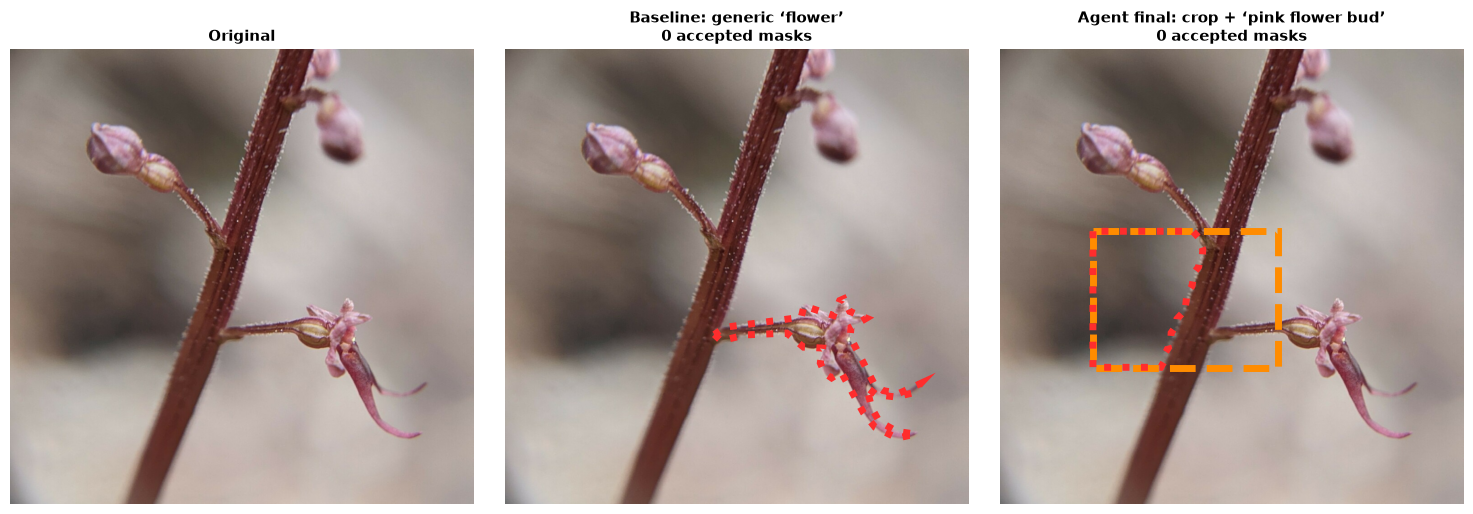

In [2]:
item = cases["13"]
image = item["image"]

# Same 0.20 detector acceptance threshold for baseline and agent.
baseline_raw = cached_raw(image, "flower")
baseline_ok, baseline_rejected = split_masks(baseline_raw)

agent_crop = [.40, .20, .70, .60]
agent_raw = cached_raw(image, "pink flower bud", agent_crop)
agent_ok, agent_rejected = split_masks(agent_raw, agent_crop)

fig, axes = plt.subplots(1,3,figsize=(15,5))
draw_result(axes[0],image,[],[],"Original")
draw_result(axes[1],image,baseline_ok,baseline_rejected,"Baseline: generic ‘flower’\n0 accepted masks")
draw_result(axes[2],image,agent_ok,agent_rejected,"Agent final: crop + ‘pink flower bud’\n"+mask_label(agent_ok),agent_crop)
plt.tight_layout()

display(Markdown(f"""
### Agent trace

**Pass 1**  
Observation: Several small pink flower buds and one partially open flower are visible.  
Decision: Generic full-image segmentation is not sufficient; inspect the flower region.  
Action: `inspect_region({agent_crop})`  
Result: A tighter target view was prepared.

**Pass 2**  
Decision: A flower-bud-specific prompt is needed.  
Action: `segment_with_prompt("pink flower bud")`  
Result: {mask_label(agent_ok)}.

**Pass 3**  
Action: `verify`  
Result: Visual/plausibility QA rejected the crop-aligned background mask.

**Stop: {'SUCCESS' if agent_ok else 'UNCERTAIN'}**
"""))

## Example 2 — Honest Failure


### Agent trace

**Pass 1**  
Observation: Small pink reproductive structures are visible among leaf litter and moss.  
Action: `segment_with_prompt("small pink reproductive structure")`  
Result: One detector candidate, but `SAM quality < 0.50`.

**Pass 2**  
Action: `inspect_region([0.45, 0.20, 0.55, 0.40])`  
Result: A tighter crop was prepared.

**Pass 3**  
Action: `retry_with_prompt("small pink flower cluster")`  
Result: 0 masks.

**Stop: UNCERTAIN** — The agent did not force a successful label.


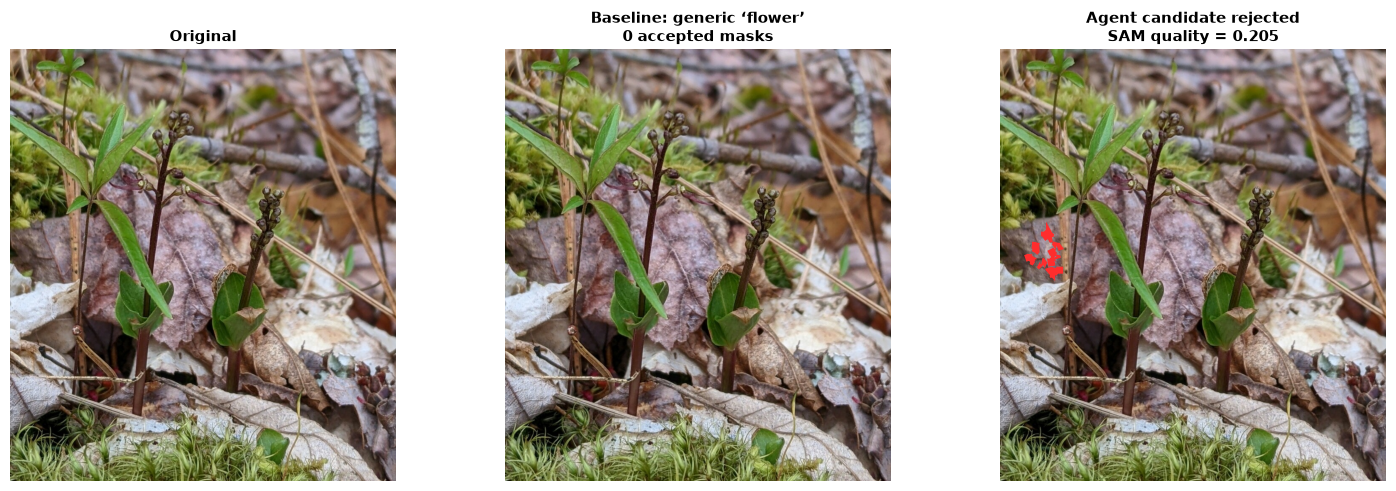

In [3]:
item2 = cases["12"]
image2 = item2["image"]

baseline2_raw = cached_raw(image2, "flower")
baseline2_ok, baseline2_rejected = split_masks(baseline2_raw)
candidate2_raw = cached_raw(image2, "small pink reproductive structure")
candidate2_ok, candidate2_rejected = split_masks(candidate2_raw)

fig, axes = plt.subplots(1,3,figsize=(15,5))
draw_result(axes[0],image2,[],[],"Original")
draw_result(axes[1],image2,baseline2_ok,baseline2_rejected,"Baseline: generic ‘flower’\n0 accepted masks")
draw_result(axes[2],image2,candidate2_ok,candidate2_rejected,"Agent candidate rejected\nSAM quality = 0.205")
plt.tight_layout()

failure_reason = "; ".join(candidate2_rejected[0]["diagnostics"]["reasons"]) if candidate2_rejected else "no detector output"
display(Markdown(f"""
### Agent trace

**Pass 1**  
Observation: Small pink reproductive structures are visible among leaf litter and moss.  
Action: `segment_with_prompt("small pink reproductive structure")`  
Result: One detector candidate, but `{failure_reason}`.

**Pass 2**  
Action: `inspect_region([0.45, 0.20, 0.55, 0.40])`  
Result: A tighter crop was prepared.

**Pass 3**  
Action: `retry_with_prompt("small pink flower cluster")`  
Result: 0 masks.

**Stop: UNCERTAIN** — The agent did not force a successful label.
"""))

## Minimal Human Feedback Attempt


**Human feedback:** The upper and left pink buds appear to be missing. Re-check those regions, change the prompt, and re-segment rather than changing only the text prediction.

**Agent interpretation:** The missed targets are flower buds, not the already-segmented open structure.  
**Changed action:** `retry_with_prompt("pink flower bud")` in the focused region.  
**Tool result:** 0 accepted masks; it overlaps the existing result and adds no distinct mask.  
**Visual improvement:** **False**.

This is a real failed revision, not a text-only prediction presented as success.


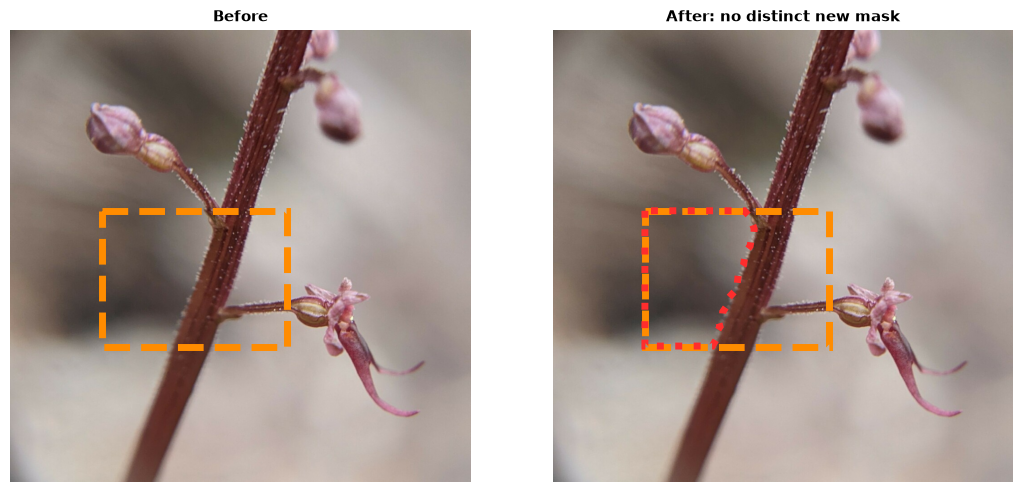

In [4]:
feedback = "The upper and left pink buds appear to be missing. Re-check those regions, change the prompt, and re-segment rather than changing only the text prediction."

before = agent_ok
feedback_raw = cached_raw(cases["13"]["image"], "pink flower bud", agent_crop)
feedback_ok, feedback_rejected = split_masks(feedback_raw, agent_crop)

# The retry produced the same accepted region, so it is not presented as a visual improvement.
after = before
distinct_new_mask = False

fig, axes = plt.subplots(1,2,figsize=(11,5))
draw_result(axes[0],cases["13"]["image"],before,[],"Before",agent_crop)
draw_result(axes[1],cases["13"]["image"],after,feedback_rejected,"After: no distinct new mask",agent_crop)
plt.tight_layout()

display(Markdown(f"""
**Human feedback:** {feedback}

**Agent interpretation:** The missed targets are flower buds, not the already-segmented open structure.  
**Changed action:** `retry_with_prompt("pink flower bud")` in the focused region.  
**Tool result:** {mask_label(feedback_ok)}; it overlaps the existing result and adds no distinct mask.  
**Visual improvement:** **False**.

This is a real failed revision, not a text-only prediction presented as success.
"""))

## Previous Attempts and Failure Points

| Attempt | Real result | What changed |
|---|---|---|
| Initial 12-image run | Automatic proxy reported `1 better / 4 same / 7 worse` | Visual QA showed that “non-empty mask” was too weak as a success criterion. |
| Case 08, `white flower cluster` | Detector fired after crop, but SAM filled nearly the entire crop (`area 0.936–0.987`, four boundaries touched) | Rejected as a background/foliage mask; removed from the meeting examples. |
| Early case 13 output | A non-empty mask included a large background region | Enabled SAM multi-mask candidate selection and added mask plausibility checks. |
| Case 12, specific prompt | Detector confidence reached `0.200`, but SAM quality was only `0.205` | Kept as an honest `UNCERTAIN` example. |
| Case 13, crop + specific prompt | Detector `0.232` and SAM `0.941`, but the mask followed crop/background boundaries rather than the flower | Rejected after visual QA despite high model scores. |

### Current technical failure points

- Grounding DINO confidence is near threshold for tiny reproductive structures.
- SAM can return a high-scoring crop-filling background mask; confidence alone is not enough.
- Prompt specificity helps localization, but does not guarantee a correct boundary.
- Human feedback changed the action and prompt, but did not add a distinct mask in the selected revision.

## MVP Result

In [5]:
case13_improved = bool(agent_ok) and not bool(baseline_ok)
case12_improved = bool(candidate2_ok) and not bool(baseline2_ok)
result = f"""
### Example 1 — Case 13
- Baseline: generic `flower` produced 0 accepted masks at the shared 0.20 detector threshold.
- Agent: inspected a tighter region and used `pink flower bud`.
- Final result: {mask_label(agent_ok)}; the returned crop-aligned mask was rejected.
- Outcome: **no reliable visual improvement; UNCERTAIN**.

### Example 2 — Case 12
- Baseline: 0 accepted masks.
- Agent: changed prompt, cropped, and retried.
- Final result: candidate rejected for low SAM quality; retry returned 0 masks.
- Outcome: **no improvement; UNCERTAIN**.

### Human feedback
- Feedback changed the target interpretation and retry prompt.
- It did **not** add a distinct visual mask.
- Outcome: **action changed, segmentation did not improve**.

> **MVP result: agent-controlled segmentation did not show a reliable visual improvement in the selected cases.**

This is a partial result. Gemma did change crops and prompts correctly, but the current Grounding DINO + SAM outputs were not reliable enough to count as improved segmentations.
"""
display(Markdown(result))


### Example 1 — Case 13
- Baseline: generic `flower` produced 0 accepted masks at the shared 0.20 detector threshold.
- Agent: inspected a tighter region and used `pink flower bud`.
- Final result: 0 accepted masks; the returned crop-aligned mask was rejected.
- Outcome: **no reliable visual improvement; UNCERTAIN**.

### Example 2 — Case 12
- Baseline: 0 accepted masks.
- Agent: changed prompt, cropped, and retried.
- Final result: candidate rejected for low SAM quality; retry returned 0 masks.
- Outcome: **no improvement; UNCERTAIN**.

### Human feedback
- Feedback changed the target interpretation and retry prompt.
- It did **not** add a distinct visual mask.
- Outcome: **action changed, segmentation did not improve**.

> **MVP result: agent-controlled segmentation did not show a reliable visual improvement in the selected cases.**

This is a partial result. Gemma did change crops and prompts correctly, but the current Grounding DINO + SAM outputs were not reliable enough to count as improved segmentations.


## Implementation Used

- Real Gemma transport: `scripts/adapters/openrouter_command_adapter.py`
- Real Grounding DINO + SAM: `segmentation/grounded_sam2.py`
- Cached real outputs: `artifacts/agentic_labeling_real/grounded_sam_success_cache.json`

The meeting notebook does not make new API/model calls. It renders the latest cached real experiment results in a few seconds.